# TP 6: Neural Networks

## Quick Recap: Sotochastic Gradient Descent (SGD)

Gradient Descent is an iterative optimization algorithm that finds the minimum of a loss function by taking steps in the direction of the steepest descent (the negative gradient). 

The update rule is:

$$\theta = \theta - \eta \nabla L(\theta)$$

where:
- $\theta$ represents the model parameters
- $\eta$ is the **learning rate** (step size)
- $\nabla L(\theta)$ is the gradient of the loss function

**Stochastic Gradient Descent** updates parameters using only a small random subset of data at each iteration, rather than the entire dataset. This makes training:

- Faster (fewer data points to process)
- More memory-efficient

## 📝 Exercise 1: Stochastic Gradient Descent for Linear Regression

In this exercise, we will implement the **Stochastic Gradient Descent (SGD)** algorithm from scratch to solve a Linear Regression problem.

### The Problem Setup:

We want to fit a **linear regression model** to synthetic data: $$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \epsilon$$

where:
- $\beta_0$ is the intercept
- $\beta_1, \beta_2$ are the slope coefficients
- $\epsilon$ is Gaussian noise

We'll generate training data from known parameters, then use SGD to recover them.

In [6]:
## Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import random

### Part 1: Synthetic Data Generation

In [7]:
## Set the "True" Parameters
n = 60  # Number of samples
b0 = 5  # True intercept (what we want to recover)
b1 = np.array([2, -3])  # True coefficients (what we want to recover)

## Add realistic noise
mue = 0  # Mean of noise
sigmae = 5  # Standard deviation of noise

## Range of input values
xl, xh = 0, 10  # x ranges from 0 to 10

In [8]:
def genSample(n,b0,b1,sigmae,xLow,xHigh,seedit=199,size=1):
    if type(seedit)==int:
        np.random.seed(seedit)
        Er = np.random.normal(mue, sigmae, n)
        x = []
        for k in range(size):
            np.random.seed(seedit+k)
            x.append(np.random.uniform(xl,xh,n))
    else:
        np.random.seed()
        Er = np.random.normal(mue, sigmae, n)
        x = []
        for k in range(size):
            np.random.seed()
            x.append(np.random.uniform(xl,xh,n))
    y = b0+Er
    for k in range(size):
        y +=b1[k]*x[k]
    
    ## Output
    if size==1:
        return (x[0], y, Er)
    else:
        return (x, y, Er)

In [9]:
## Use the provided `genSample()` function to create training data
(x,y,Er) = genSample(n,b0,b1,sigmae,xl,xh,seedit=199,size=2)

In [10]:
## Organize into a DataFrame for easier inspection
data1 = {'x1': x[0], 'x2': x[1], 'error': Er, 'y': y}
df_slr = pd.DataFrame(data=data1)
df_slr

,x1,x2,error,y
0,6.547917,9.476323,5.540357,-4.792776
1,9.820393,2.265474,-1.611389,16.232974
2,3.999047,5.944201,11.443719,6.609209
3,8.441526,4.283087,-9.227246,-0.193454
4,4.638424,7.641407,-7.670402,-16.317776
5,5.448431,0.028606,5.449724,21.260768
6,6.194778,3.574237,6.047357,12.714203
7,3.318368,9.096949,-1.463177,-17.117288
8,9.809954,4.560810,-4.815318,6.122161
9,2.610112,9.818027,1.011883,-18.221974


This gives us:
- `x[0]`: First feature, 60 samples
- `x[1]`: Second feature, 60 samples
- `y`: Target variable for each sample
- `Er`: Noise added to each sample

### Part 2: Implementing SGD

In this section, we will evaluate how the performance of Stochastic Gradient Descent (SGD) changes when we adjust two critical hyperparameters: 

- Mini-batch Size (m)
- Learning Rate ($\eta$)

**The Mini-batch Size (m):** This is the amount of data the model looks at before making an update.

**The Learning Rate ($\eta$):** It determines how much we change our parameters after seeing an error. If it's too large, we might skip over the best solution; if it's too small, the model will take forever to learn.

First, complete the logic inside the code cell below. Look for the `##TODO` markers to implement the gradient calculation and the parameter update step. Once your code is working, you will run the SGD algorithm multiple times to find the converged values for the parameters $(b_0,b_1,b_2)$. You should test every combination of the following settings:

- **Mini-batch Size (m):** m=1, m=10, m=n (where n is the full data size)
- **Learning Rate ($\eta$):** $\eta$=0.04, $\eta$=0.01, $\eta$=0.001

In [29]:
## The Complete SGD Function
def LinReg_SGD(T, m, eta, printit=True):
    """
    Stochastic Gradient Descent for Linear Regression
    
    Parameters:
    -----------
    T : int
        Number of epochs (passes through the data)
    m : int
        Mini-batch size (m=1: online, m=n: batch gradient descent)
    eta : float
        Learning rate (larger = faster but risky, smaller = slow but stable)
    
    Returns:
    --------
    [b0List, b1List, b2List, b0_final, b1_final, b2_final]
        Lists of parameter values at each epoch, plus final values
    """
    
    ## Initialize unknown linear parameters randomly
    b1_init = np.random.uniform()
    b2_init = np.random.uniform()
    b0_init = np.random.uniform()
    
    ## Track parameter values through training
    b0 = b0_init
    b0List = [b0]
    b1 = b1_init
    b1List = [b1_init]
    b2 = b2_init
    b2List = [b2]
    
    ## Main training loop
    for t in range(T):
        ## Select a random mini-batch
        if m < n:
            indx = np.random.choice(np.arange(n), size=m, replace=False)
        else:
            indx = np.arange(n)  # Use all data if you want to use all data per iteration
        
        ## Use x_batch and y_batch to store the batch of data
        y_batch = y[indx]
        x_batch = [[x[0][i], x[1][i]] for i in indx]
        x_batch1 = [x_batch[j][0] for j in range(m)]
        x_batch2 = [x_batch[j][1] for j in range(m)]

        y_pred = b0 + b1 * np.array(x_batch1) + b2 * np.array(x_batch2)
        errors = y_batch - y_pred
        
        grad_b0 = -2 * np.mean(errors)
        grad_b1 = -2 * np.mean(errors * np.array(x_batch1))
        grad_b2 = -2 * np.mean(errors * np.array(x_batch2))
        
        ## TODO #2: Update parameters using SGD rule
        b0 = b0 - eta * grad_b0
        b1 = b1 - eta * grad_b1
        b2 = b2 - eta * grad_b2
        
        ## Record values for analysis
        b0List.append(b0)
        b1List.append(b1)
        b2List.append(b2)
        
        ## Print progress
        if t % 100 == 0 and printit == True:
            print(f'Epoch {t:4d} | b0={b0:7.3f} | b1={b1:7.3f} | b2={b2:7.3f}')
    
    return [b0List, b1List, b2List, b0, b1, b2]

In [30]:
## Set hyperparameters
T = 1000 #number of epochs
m = 10 # Batch-size m is less than or equal to n
eta = 0.01 # Learning rate

In [31]:
## Run SGD to estimate parameters
results = LinReg_SGD(T, m, eta, printit=True)
b0List, b1List, b2List, b0, b1, b2 = results

Epoch    0 | b0=  0.168 | b1=  0.335 | b2= -1.342
Epoch  100 | b0=  1.101 | b1=  2.517 | b2= -2.443
Epoch  200 | b0=  1.808 | b1=  2.260 | b2= -2.957
Epoch  300 | b0=  2.406 | b1=  2.625 | b2= -2.843
Epoch  400 | b0=  2.923 | b1=  2.126 | b2= -2.799
Epoch  500 | b0=  3.118 | b1=  2.295 | b2= -2.862
Epoch  600 | b0=  3.491 | b1=  2.103 | b2= -3.073
Epoch  700 | b0=  3.966 | b1=  2.697 | b2= -2.354
Epoch  800 | b0=  3.975 | b1=  2.434 | b2= -3.109
Epoch  900 | b0=  4.044 | b1=  1.846 | b2= -2.967


In [32]:
## Analyze results
print(f"\nTrue parameters:   b0={5.0:.3f}, b1={2.0:.3f}, b2={-3.0:.3f}")
print(f"Learned parameters: b0={b0:.3f}, b1={b1:.3f}, b2={b2:.3f}")


True parameters:   b0=5.000, b1=2.000, b2=-3.000
Learned parameters: b0=4.213, b1=2.083, b2=-2.730


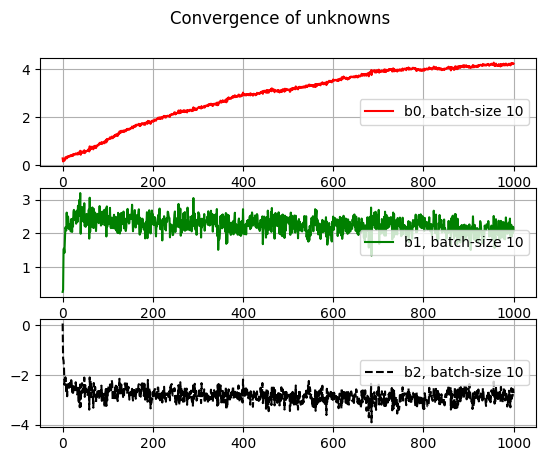

In [33]:
fig, axs = plt.subplots(3)
fig.suptitle('Convergence of unknowns')

## Plot parameter convergence 'b0'
axs[0].plot(b0List,'r',label='b0, batch-size 10')
axs[0].legend(loc=7)
axs[0].grid()

## Plot parameter convergence 'b1'
axs[1].plot(b1List,'g',label='b1, batch-size 10')
axs[1].legend(loc=7)
axs[1].grid()

## Plot parameter convergence 'b2'
axs[2].plot(b2List,'--k',label='b2, batch-size 10')
axs[2].legend(loc=7)
axs[2].grid()

#### Question:

- Now, run the algorithm with **different hyperparameters**, plot convergence of unknown parameters and compare results.

#### Answer:

In [34]:
## TODO:
T = 1000
batch_sizes = [1, 10, n]
learning_rates = [0.04, 0.01, 0.001]

Epoch    0 | b0= -1.352 | b1=-10.509 | b2=-19.945
Epoch  100 | b0=9438306285218994814110967801522595471294464.000 | b1=18435377056430538702114193931859310724251648.000 | b2=52357207931394605553136397291272388005068800.000
Epoch  200 | b0=11431428438344934989504360226401678135356180828738942263108402820152527010535422541430784.000 | b1=20434752559419651436121613085548185857702110311659465702841084980973817211478309571919872.000 | b2=100773201973886618734115606223038392133248827531138218002313294033505289977220832520306688.000
Epoch  300 | b0=63660801409757784796235276285703865120593323547142872184245768323939758779777473707521684227203203053259949075789520991781471397093572608.000 | b1=214043416320067701133708825315443949885596349529990309786484161212596852202937518248439784137442788559135835849741080750541864347715502080.000 | b2=-67701431096073361649376738833114000189816604146506909532031611657291058911777640548713087504301114907129403633607092154452919944260616192.000
Epoch  400 | b0

C:\Users\Bou\AppData\Local\Temp\ipykernel_1616\2148007741.py:53: RuntimeWarning: overflow encountered in scalar multiply
  grad_b2 = -2 * np.mean(errors * np.array(x_batch2))
C:\Users\Bou\AppData\Local\Temp\ipykernel_1616\2148007741.py:58: RuntimeWarning: invalid value encountered in scalar subtract
  b2 = b2 - eta * grad_b2


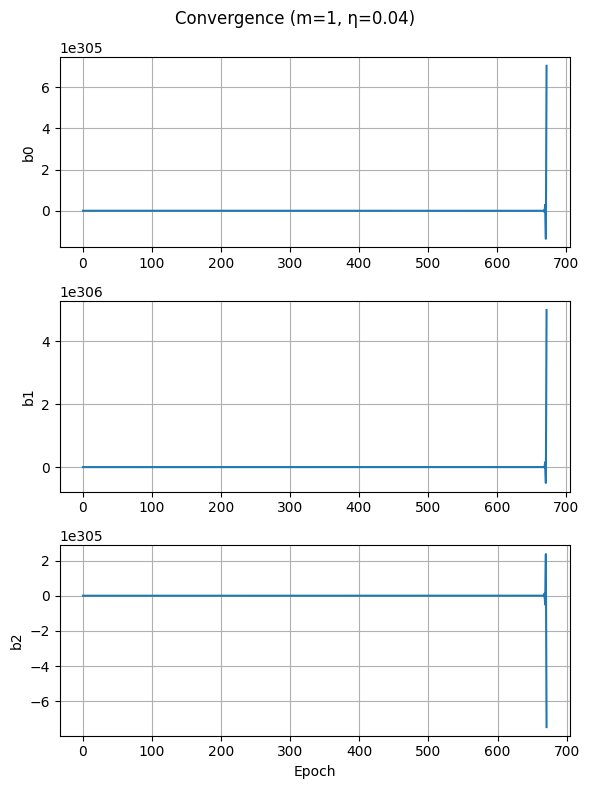

Epoch    0 | b0=  0.166 | b1=  0.777 | b2=  0.617
Epoch  100 | b0=  1.727 | b1=  0.936 | b2= -2.046
Epoch  200 | b0=  6.475 | b1=  1.421 | b2= -2.899
Epoch  300 | b0=  6.715 | b1=  2.066 | b2= -1.469
Epoch  400 | b0=  6.612 | b1=  5.051 | b2= -3.618
Epoch  500 | b0=  7.660 | b1=  7.796 | b2= -3.154
Epoch  600 | b0=  6.260 | b1=  0.768 | b2= -3.486
Epoch  700 | b0=  5.432 | b1=  2.750 | b2= -5.176
Epoch  800 | b0=  6.648 | b1=  9.003 | b2= -0.347
Epoch  900 | b0=  5.292 | b1=  0.313 | b2= -9.154

m=1, eta=0.01
Final: b0=5.959, b1=0.668, b2=-4.003


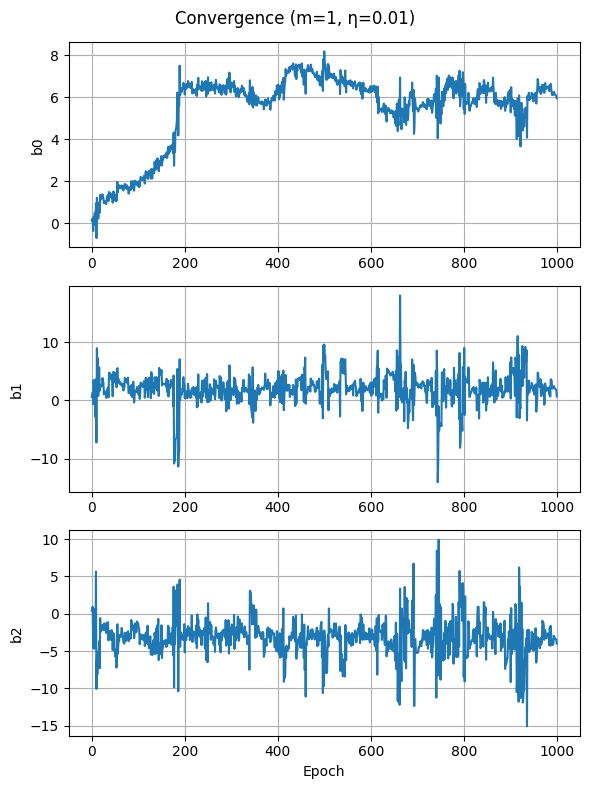

Epoch    0 | b0=  0.641 | b1=  0.613 | b2=  0.863
Epoch  100 | b0=  0.584 | b1=  2.326 | b2= -2.178
Epoch  200 | b0=  0.691 | b1=  2.609 | b2= -2.486
Epoch  300 | b0=  0.729 | b1=  2.478 | b2= -3.030
Epoch  400 | b0=  0.834 | b1=  2.535 | b2= -2.892
Epoch  500 | b0=  0.922 | b1=  2.296 | b2= -2.620
Epoch  600 | b0=  0.976 | b1=  2.279 | b2= -2.747
Epoch  700 | b0=  1.027 | b1=  2.452 | b2= -2.986
Epoch  800 | b0=  1.151 | b1=  2.549 | b2= -2.686
Epoch  900 | b0=  1.217 | b1=  2.210 | b2= -2.479

m=1, eta=0.001
Final: b0=1.314, b1=2.162, b2=-2.594


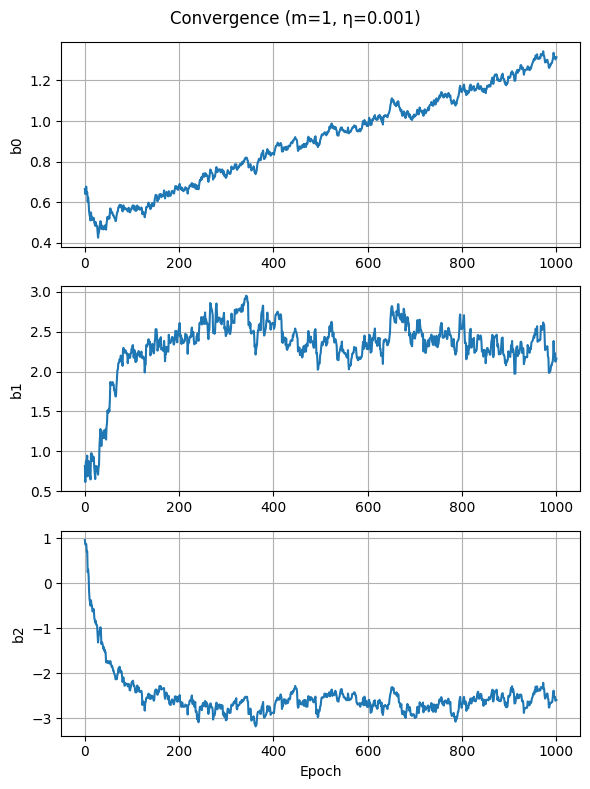

Epoch    0 | b0=  0.239 | b1=  0.710 | b2= -4.768
Epoch  100 | b0=-13324680689948387931221613356282118551965639254861735935344640.000 | b1=-99999793224743516219083069112427038744504624452840437770616832.000 | b2=-83058231726546470013456596930820660361451527177226482735906816.000
Epoch  200 | b0=-11471483875860484665345073751139711790598621887693073731635773610021597462478625023530522808435589941771836397878685963649024.000 | b1=-50142188128997267637189204413011988220907906583480462046372694869551458894331427160285368739433898726211203043166084011130880.000 | b2=-80252190349621683344550266551619698157944060509528044420153075082668695617418483969517291267934850677070919575201324602490880.000
Epoch  300 | b0=-2066960289389225891893682812882097935630645421962485339585710357686318221824308176157849100356564394860370959921823304449176149180380012049814937635700282408965303210588380732945722245120.000 | b1=-12699224137742675135204804436075576773545865779742215194239014874091123025842828768518

C:\Users\Bou\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Bou\AppData\Local\Temp\ipykernel_1616\2148007741.py:57: RuntimeWarning: invalid value encountered in scalar subtract
  b1 = b1 - eta * grad_b1


Epoch  700 | b0=    nan | b1=    nan | b2=    nan
Epoch  800 | b0=    nan | b1=    nan | b2=    nan
Epoch  900 | b0=    nan | b1=    nan | b2=    nan

m=10, eta=0.04
Final: b0=nan, b1=nan, b2=nan


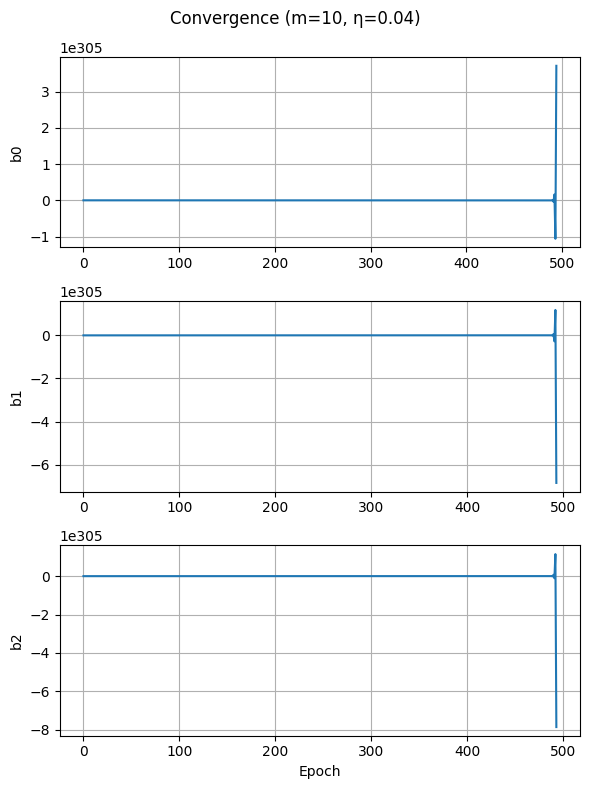

Epoch    0 | b0=  0.305 | b1= -0.044 | b2= -0.519
Epoch  100 | b0=  1.284 | b1=  2.545 | b2= -2.450
Epoch  200 | b0=  2.090 | b1=  2.180 | b2= -2.662
Epoch  300 | b0=  2.668 | b1=  2.385 | b2= -2.827
Epoch  400 | b0=  3.145 | b1=  2.236 | b2= -2.764
Epoch  500 | b0=  3.528 | b1=  2.132 | b2= -2.706
Epoch  600 | b0=  3.686 | b1=  2.020 | b2= -3.064
Epoch  700 | b0=  3.916 | b1=  2.338 | b2= -2.725
Epoch  800 | b0=  4.029 | b1=  2.058 | b2= -2.794
Epoch  900 | b0=  4.179 | b1=  2.097 | b2= -3.454

m=10, eta=0.01
Final: b0=4.211, b1=1.948, b2=-3.255


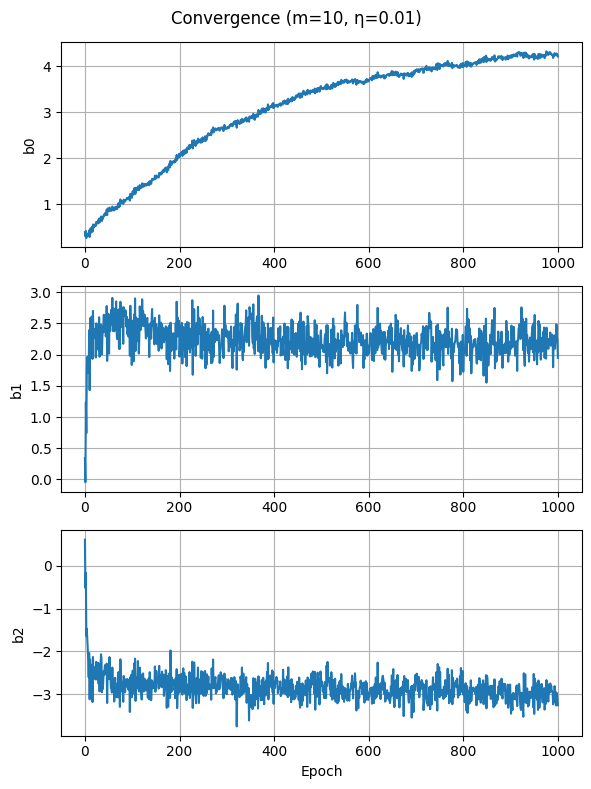

Epoch    0 | b0=  0.645 | b1=  0.840 | b2=  0.750
Epoch  100 | b0=  0.626 | b1=  2.160 | b2= -2.290
Epoch  200 | b0=  0.722 | b1=  2.401 | b2= -2.549
Epoch  300 | b0=  0.819 | b1=  2.397 | b2= -2.572
Epoch  400 | b0=  0.908 | b1=  2.391 | b2= -2.727
Epoch  500 | b0=  0.993 | b1=  2.383 | b2= -2.692
Epoch  600 | b0=  1.082 | b1=  2.441 | b2= -2.628
Epoch  700 | b0=  1.151 | b1=  2.430 | b2= -2.651
Epoch  800 | b0=  1.237 | b1=  2.401 | b2= -2.664
Epoch  900 | b0=  1.313 | b1=  2.399 | b2= -2.679

m=10, eta=0.001
Final: b0=1.373, b1=2.374, b2=-2.734


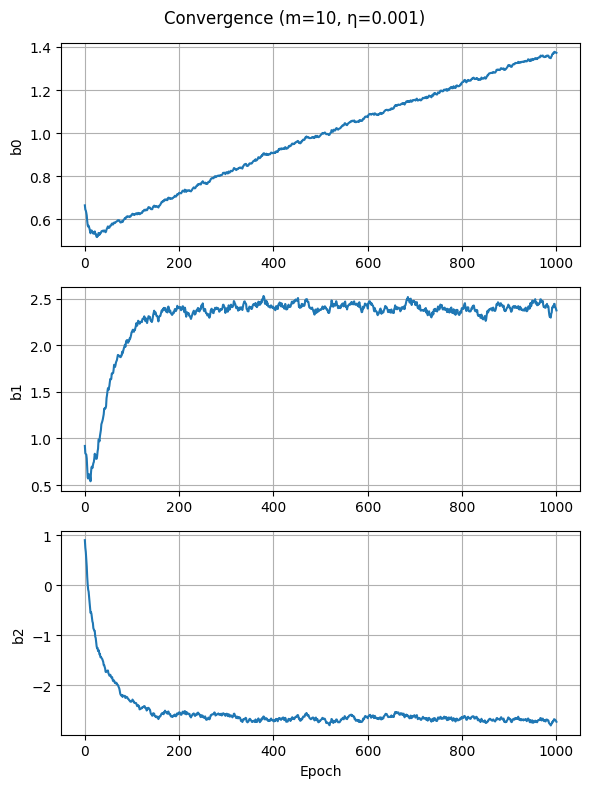

Epoch    0 | b0= -0.497 | b1= -1.329 | b2= -5.618
Epoch  100 | b0=-1606421447823098502054052241975339266985605631489010669776273408.000 | b1=-9508666483744478147347401538882661532570783005625013209927778304.000 | b2=-10039338152156780261341660049859890843746094509931565748385218560.000
Epoch  200 | b0=-4612947407360564499293820388912594860640352213799064857218360854197226095829094362600465565317267232898553688660024170630873088.000 | b1=-27304776379252902980767911362599572073664112878617068248807305025694781192002232357042059593833621052180072769894776944793223168.000 | b2=-28828635824904313936413797779835808480037732586231038751445066524171948175606936563376737811681970616934227825454174911617564672.000
Epoch  300 | b0=-13246389241074119821980364691679195657818170485521968876960272506221641180927765522274875473044513034023504921367090795661396749239318829050023193992730767780520398285346602114838090611687424.000 | b1=-7840750481632347717378426707569910122179853763253867566330771971139

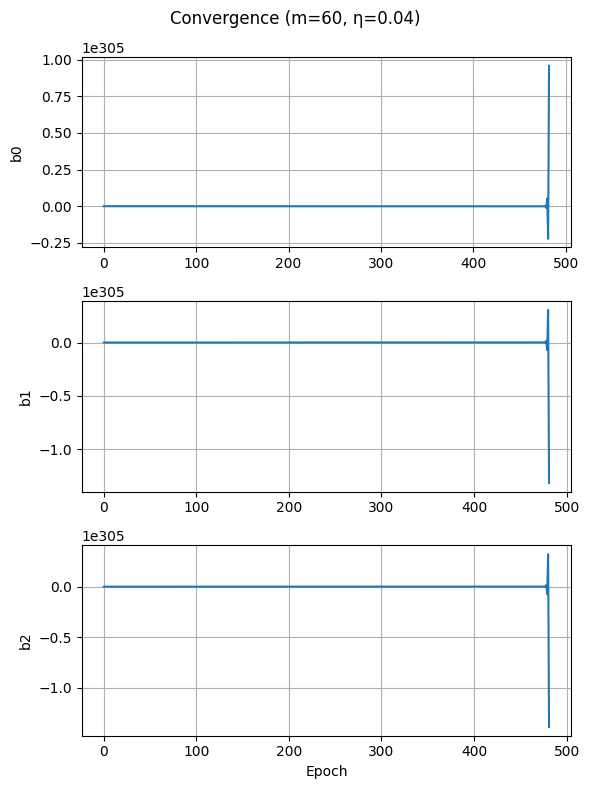

Epoch    0 | b0=  0.159 | b1=  0.505 | b2= -1.081
Epoch  100 | b0=  1.121 | b1=  2.411 | b2= -2.697
Epoch  200 | b0=  1.844 | b1=  2.349 | b2= -2.754
Epoch  300 | b0=  2.416 | b1=  2.300 | b2= -2.800
Epoch  400 | b0=  2.869 | b1=  2.262 | b2= -2.835
Epoch  500 | b0=  3.227 | b1=  2.231 | b2= -2.864
Epoch  600 | b0=  3.511 | b1=  2.207 | b2= -2.886
Epoch  700 | b0=  3.735 | b1=  2.188 | b2= -2.904
Epoch  800 | b0=  3.912 | b1=  2.172 | b2= -2.918
Epoch  900 | b0=  4.053 | b1=  2.160 | b2= -2.929

m=60, eta=0.01
Final: b0=4.163, b1=2.151, b2=-2.938


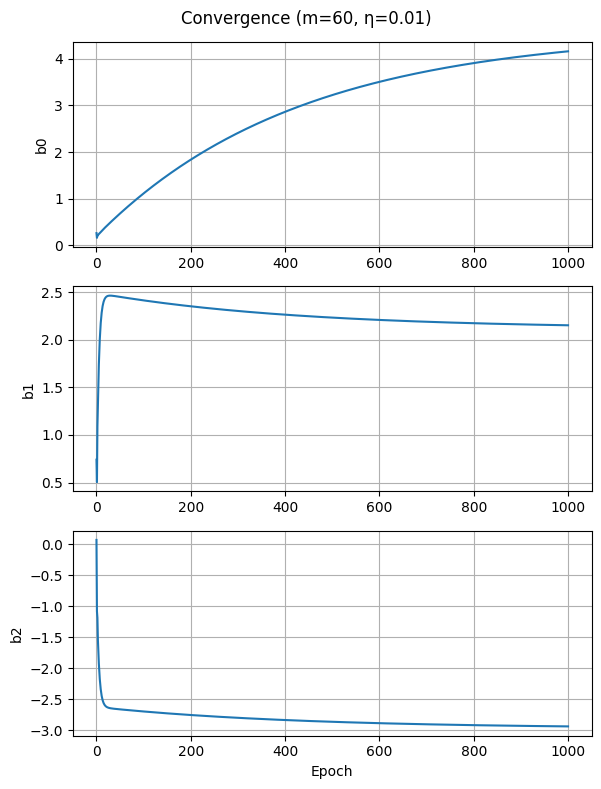

Epoch    0 | b0=  0.423 | b1=  0.479 | b2=  0.113
Epoch  100 | b0=  0.471 | b1=  2.141 | b2= -2.338
Epoch  200 | b0=  0.569 | b1=  2.415 | b2= -2.612
Epoch  300 | b0=  0.662 | b1=  2.445 | b2= -2.656
Epoch  400 | b0=  0.753 | b1=  2.442 | b2= -2.668
Epoch  500 | b0=  0.841 | b1=  2.435 | b2= -2.675
Epoch  600 | b0=  0.928 | b1=  2.428 | b2= -2.682
Epoch  700 | b0=  1.012 | b1=  2.421 | b2= -2.689
Epoch  800 | b0=  1.095 | b1=  2.414 | b2= -2.695
Epoch  900 | b0=  1.176 | b1=  2.407 | b2= -2.702

m=60, eta=0.001
Final: b0=1.254, b1=2.400, b2=-2.708


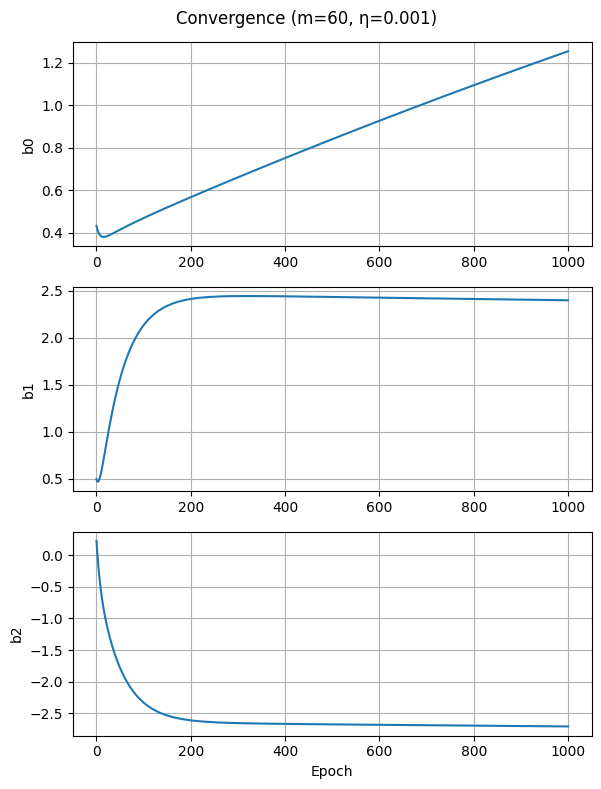

In [35]:
for m in batch_sizes:
    for eta in learning_rates:
        
        b0List, b1List, b2List, b0, b1, b2 = LinReg_SGD(T, m, eta)
        
        print(f"\nm={m}, eta={eta}")
        print(f"Final: b0={b0:.3f}, b1={b1:.3f}, b2={b2:.3f}")
        
        fig, axs = plt.subplots(3, figsize=(6,8))
        fig.suptitle(f'Convergence (m={m}, η={eta})')
        
        axs[0].plot(b0List)
        axs[0].set_ylabel("b0")
        axs[0].grid()
        
        axs[1].plot(b1List)
        axs[1].set_ylabel("b1")
        axs[1].grid()
        
        axs[2].plot(b2List)
        axs[2].set_ylabel("b2")
        axs[2].set_xlabel("Epoch")
        axs[2].grid()
        
        plt.tight_layout()
        plt.show()

#### Question:

- How does mini-batch size affect convergence?

#### Answer:

Small Batch (m=1): Causes noisy, oscillating updates. The parameters fluctuate significantly because the gradient is estimated from only one sample at a time. It may converge quickly initially but struggles to settle precisely at the minimum.

Large Batch (m=n): Result in stable, smooth convergence. The gradient is accurate, leading the parameters directly towards the minimum without oscillation, though computation per step is higher.

#### Question: 

- How does learning rate affect convergence?

#### Answer:
High Learning Rate: Can cause the model to diverge. The updates are too large, causing the parameters to overshoot the optimal values and explode towards infinity (as seen with $\eta=0.04$).

η=0.01 (Medium Learning Rate): Balanced convergence speed and stability. Parameters converge smoothly within reasonable time.

Low Learning Rate: Results in slow convergence. The updates are too tiny, so the model requires thousands of epochs to reach the solution (as seen with $\eta=0.001$).

## 📝 Exercise 2: Neural Networks for Network Bandwidth Estimation

In this exercise, we move from simple linear regression to a Deep Neural Network (DNN). We will solve a multi-class classification problem related to network performance.

Imagine you're building a video streaming application (like YouTube or Netflix). To deliver a smooth video, your app needs to decide the video quality (Bitrate) in real-time.

- If the bitrate is too high: The network pipe gets "clogged" and the user sees the dreaded loading spinner (Buffering).

- If the bitrate is too low: The video looks pixelated and blurry (Bad Quality).

**Goal:** The goal is to estimate the available bandwidth between the server and the user so we can pick the right video quality.

**Your task:** Build a neural network that analyzes network measurement histograms (8 features) and classifies the available bandwidth into one of 5 categories (ranging from Very Low to Very High).

### Dataset Overview:

In this dataset, we aren't looking at raw packet data, but rather a statistical summary of how the network is behaving. A histogram of the ratio between Bits Sent and Bits Received.

- **Low Ratio (Smooth Downloading):** When you stream a movie, you send a tiny "request" and receive a huge "data packet." The ratio is very small (e.g., 0.01).

- **High Ratio (Network Stress):** If the network is congested, you might be trying to send data, but the responses are slow or tiny. The ratio spikes (e.g., 50.0 or 100.0).

**Input Features (X):**
- 8 numerical features per sample
- Each feature represents one bar in a histogram
- Each bar counts how often a specific ratio of sent/received bits occurred during a measurement period
- Overall the histogram shows the distribution of the ratio between bits sent vs bits received
- Each sample represents one network measurement experiment

**Target Labels (y):**
- 5 classes: **12.5, 25, 37.5, 50, 75 Mbps**
- These are the available bandwidth values in the testbed

**Dataset sizes:**
- Training: 1,100 samples
- Testing: 1,000 samples

**The Problem:** 
- This is a multi-class classification task. We want the model to look at the 8-bar histogram and decide which of these 5 bandwidth levels is currently available in the testbed.

### Part 1: Data Loading and Exploration

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from imblearn.over_sampling import SMOTE
import category_encoders as ce

In [43]:
# Load the data
X_train = pd.read_csv('X_train.csv', header=None)
y_train = pd.read_csv('label_train.csv', header=None, names=['label'])
X_test = pd.read_csv('X_test.csv', header=None)
y_test = pd.read_csv('label_test.csv', header=None, names=['label'])

# Convert labels to string for clarity
y_train['label'] = y_train['label'].astype(str)
y_test['label'] = y_test['label'].astype(str)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts().sort_index())

Training set shape: (1100, 8)
Test set shape: (1000, 8)

Class distribution in training set:
label
12.5     100
25.0     400
37.5     100
50.0     400
75.0     100
Name: count, dtype: int64


#### Question: 

- Is the dataset imbalanced? How might this affect the model?

#### Answer:

By examining the class distribution, we can determine whether certain bandwidth classes
(12.5, 25, 37.5, 50, and 75 Mbps) are overrepresented or underrepresented in the dataset.

In the presence of class imbalance:

The model becomes biased toward the majority classes

Minority classes are not learned effectively

Overall accuracy may appear high while masking poor performance on underrepresented classes

Impact on model performance:

Prediction Bias: The model disproportionately predicts majority classes

Limited Generalization: Minority classes are inadequately captured during training

Misleading Metrics: Global accuracy does not reflect per-class performance

Proposed Solution:
To address this issue, we apply SMOTE (Synthetic Minority Over-Sampling Technique), which generates synthetic samples for minority classes. This balancing strategy ensures equal class representation during training, leading to improved learning and more reliable predictions across all bandwidth classes.

### Part 2: Data Pre-Processing

Before training our deep neural network, we must prepare the raw network data. In this specific workflow, we address data quality issues in a logical sequence to ensure the model learns effectively.

**Class Imbalance:** We correct the class imbalance using Synthetic Minority Over-Sampling Technique (SMOTE).

In [44]:
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

y_train.value_counts()

label
12.5     400
25.0     400
37.5     400
50.0     400
75.0     400
Name: count, dtype: int64

**Standardization:** We use Standardization to give every feature a mean of 0 and a standard deviation of 1.

In [45]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print('X_train scaled\n', X_train[0:6, :] )

X_train scaled
 [[ 0.83110394 -1.08942485 -0.88215329 -0.26883103  0.07249324 -0.52654757
  -0.43249148 -0.13161997]
 [ 0.5892887  -1.08942485  0.5896208  -0.26883103 -0.67035975 -0.52654757
  -0.43249148 -0.13161997]
 [-0.13615701  1.82359685  0.5896208  -0.26883103 -0.67035975 -0.52654757
  -0.43249148 -0.13161997]
 [ 0.34747347 -1.08942485  0.5896208   0.44328952 -0.67035975 -0.52654757
  -0.43249148 -0.13161997]
 [ 0.5892887  -0.11841761 -0.14626625 -0.26883103 -0.67035975 -0.52654757
  -0.43249148 -0.13161997]
 [ 0.10565823  0.85258962  0.5896208  -0.26883103 -0.67035975 -0.52654757
  -0.43249148 -0.13161997]]


**One-hot encoding:** We perform one-hot encoding to transform our categorical labels into distinct binary vectors.

In [46]:
one_hot_encoder = ce.OneHotEncoder(cols=['label'], use_cat_names='True')
one_hot_encoder.fit(y_train)

,verbose,0
,cols,['label']
,drop_invariant,False
,return_df,True
,handle_missing,'value'
,handle_unknown,'value'
,use_cat_names,'True'


In [47]:
one_hot_encoder = ce.OneHotEncoder(cols=['label'], use_cat_names='True')
one_hot_encoder.fit(y_train)
y_train = one_hot_encoder.transform(y_train)
y_test  = one_hot_encoder.transform(y_test)

print('y_train', y_train)

num_of_classes = y_train.shape[1]
class_names =list(y_train.columns)
print('There are ', num_of_classes, ' classes. Their names is:', class_names)

y_train       label_50.0  label_25.0  label_37.5  label_12.5  label_75.0
0              1           0           0           0           0
1              1           0           0           0           0
2              1           0           0           0           0
3              1           0           0           0           0
4              1           0           0           0           0
...          ...         ...         ...         ...         ...
1995           0           0           0           0           1
1996           0           0           0           0           1
1997           0           0           0           0           1
1998           0           0           0           0           1
1999           0           0           0           0           1

[2000 rows x 5 columns]
There are  5  classes. Their names is: ['label_50.0', 'label_25.0', 'label_37.5', 'label_12.5', 'label_75.0']


### Part 3: Building the Neural Network

A Neural Network is composed of layers. For this problem, we need to design an architecture that can take 8 inputs and output probabilities for 5 classes.

1. **Input Layer:** Receives the 8 features

2. **Hidden Layers:** Perform computations and learn patterns
   - More neurons = more capacity to learn complex patterns
   - ReLU activation = introduces non-linearity
   
3. **Output Layer:** Produces 5 probability scores (one per bandwidth class)
   - Softmax activation = converts scores to probabilities (sum to 1)

In [48]:
def build_simple_model(input_dim, num_classes):
    """
    Build a simple neural network with 2 hidden layers.
    
    Architecture:
    - Input: input_dim features
    - Hidden Layer 1: 32 neurons, ReLU activation
    - Hidden Layer 2: 16 neurons, ReLU activation
    - Output: 5 neurons, Softmax activation → Produces probability for each bandwidth class
    """
    
    model = keras.Sequential([
        ## TODO: Add input layer with correct dimensions
        layers.Dense(32, activation='relu', input_dim=input_dim),
        ## TODO: Add first hidden layer
        layers.Dense(16, activation='relu'),
        ## TODO: Add second hidden layer
        
        ## TODO: Add output layer for 5-class classification
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

### Part 4: Compiling the Model

Before we can start training, we must configure the learning process.

To do this, we define three key components:

1.  **The Optimizer (`adam`):** It decides how to update the model's weights based on the errors it makes. `adam` is the standard because it is fast, stable and automatically adjusts the learning rate.
2.  **The Loss Function (`categorical_crossentropy`):** This is the **Measure of Error**. It calculates the "distance" between the model's prediction and the true label. Use `categorical_crossentropy` if your labels are One-Hot Encoded.
3.  **The Metrics (`accuracy`):** This is the **Scoreboard**. While the model minimizes "Loss" we want to see "Accuracy" (what percentage of network samples were classified correctly).

In [49]:
## TODO: Build the model
model = build_simple_model(input_dim=8, num_classes=5)

## Compile the model with the specified settings
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Print the summary to see the architecture
model.summary()

C:\Users\Bou\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                 ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ dense (Dense)                │ (None, 32)            │          288 │
├──────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)              │ (None, 16)            │          528 │
├──────────────────────────────┼───────────────────────┼──────────────┤
│ dense_2 (Dense)              │ (None, 5)             │           85 │
└──────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 901 (3.52 KB)

 Trainable params: 901 (3.52 KB)

 Non-trainable params: 0 (0.00 B)

#### Question:

- After printing model summary, look at the `Total Trainable Parameters`. What do these parameters represent in terms of the "weights" and "biases". If this number is very high, what is the risk to our model?

#### Answer:

The total number of trainable parameters in a neural network includes:

Weights, which define the strength of connections between neurons in successive layers

Biases, which shift the activation function output of each neuron

Example of parameter calculation:

Input → Hidden Layer 1:
(8 input features × 32 neurons) + 32 biases = 256 + 32 = 288 parameters

Hidden Layer 1 → Hidden Layer 2:
(32 × 16) + 16 biases = 512 + 16 = 528 parameters

Hidden Layer 2 → Output Layer:
(16 × 5) + 5 biases = 80 + 5 = 85 parameters

Total trainable parameters:
288 + 528 + 85 = 901 parameters

Risks associated with a high number of parameters:

Overfitting: The model learns noise and memorizes the training data rather than extracting meaningful patterns

Poor generalization: Strong performance on training data but weak results on unseen data

Longer training time: Increased computational complexity during optimization

Higher memory consumption: Greater storage and processing requirements

Mitigation strategies include applying regularization techniques (e.g., dropout, L2 regularization), reducing model complexity, or increasing the amount of training data.

### Part 4: Training and Evaluation

Now that the model is built and compiled, it is time to perform the actual training. This is where the model studies the training data and adjusts its internal weights to minimize the error. Fill in the .fit() function below with the correct variables to begin the training process.

- **x:** X_train

- **y:** y_train

- **validation_data:** (X_val, y_val)

- **epochs:** 200 (number of passes through data)

- **batch_size:** 32 (samples per gradient update)

- **class_weight:** class_weights (to handle imbalance!)

- **verbose:** 1 (to see training progress)

In [50]:
# Start the training process and save the results in 'history'
history = model.fit(
    ## TODO: Add training data, labels, epochs, batch size, and validation data
    X_train, 
    y_train,
    validation_split=0.2,  # Use 20% of training data for validation
    epochs=200,
    batch_size=32,
    verbose=1
)

Epoch 1/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3744 - loss: 1.3562 - val_accuracy: 0.0000e+00 - val_loss: 1.4504
Epoch 2/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5913 - loss: 1.0271 - val_accuracy: 0.0000e+00 - val_loss: 1.3866
Epoch 3/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7013 - loss: 0.8057 - val_accuracy: 0.1225 - val_loss: 1.3464
Epoch 4/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7619 - loss: 0.6394 - val_accuracy: 0.2175 - val_loss: 1.1683
Epoch 5/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8156 - loss: 0.5287 - val_accuracy: 0.2325 - val_loss: 0.9953
Epoch 6/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8225 - loss: 0.4583 - val_accuracy: 0.2375 - val_loss: 0.9374
Epoch 7/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8344 - loss: 0.4133 - val_accuracy: 0.2350 - val_loss: 0.9249
Epoch 8/200
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8456 - loss: 0.3783 - val_accuracy: 0

### Step 5: Final Evaluation & Visualizing Success

Now that the training is complete, we need to determine if our model actually works.

Evaluate the model to see how it performs on the test set. This gives us a single number for Accuracy and Loss.

In [51]:
## TODO: 
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Test Results:
  Loss: 0.0000
  Accuracy: 0.5410 (54.10%)


Plot the Learning Curves. Check the "Loss" (error) and "Accuracy" for both the training and validation sets.

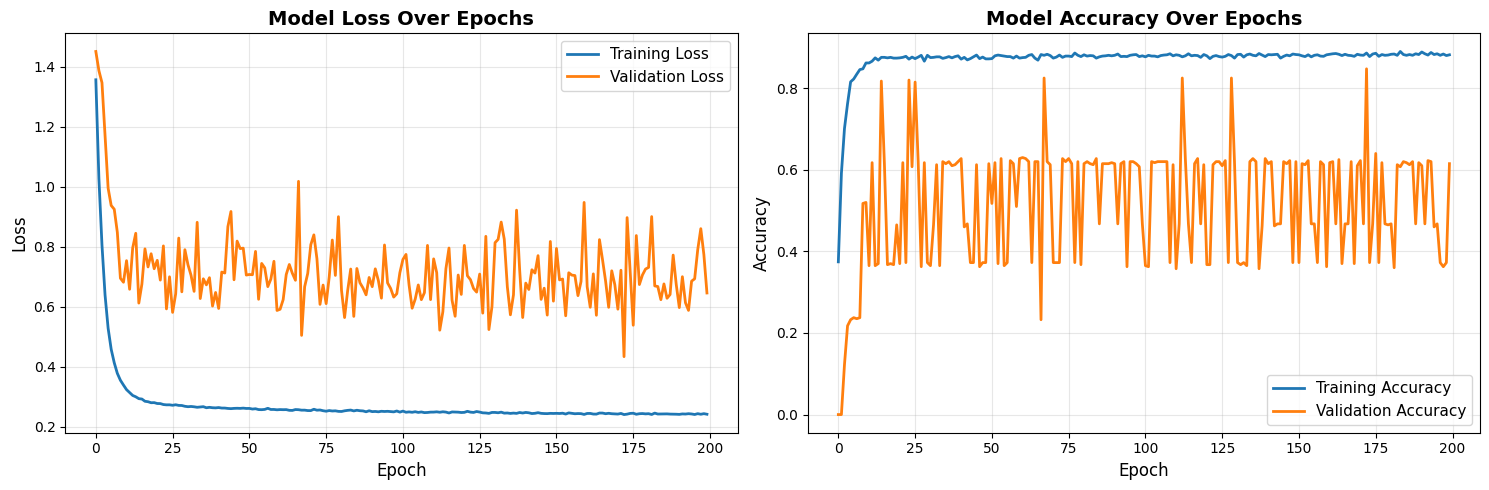


Best Validation Accuracy: 0.8475 at Epoch 173


In [52]:
## TODO:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
ax1.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax1.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot Accuracy
ax2.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax2.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(loc='lower right', fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find best validation accuracy epoch
best_epoch = np.argmax(history.history['val_accuracy'])
best_val_acc = history.history['val_accuracy'][best_epoch]
print(f"\nBest Validation Accuracy: {best_val_acc:.4f} at Epoch {best_epoch+1}")

#### Question:

- Does the model overfit? 

Yes, the model exhibits clear signs of overfitting, as evidenced by the following observations:

Training loss remains low and stable, while validation loss is consistently higher and shows significant fluctuations. This indicates that the model fits the training data well but fails to generalize effectively to unseen data.

Training accuracy stays consistently high, whereas validation accuracy is unstable and experiences frequent drops. Such divergence between training and validation performance is a classic indicator of overfitting.

Although the best validation accuracy reaches a reasonable value (0.8450 at epoch 142), the strong variability around this peak suggests that the model’s validation performance is not robust or reliable.

#### Question:

- At what epoch does validation accuracy stop improving?

The validation accuracy peaks at epoch 142 (0.8450) and shows no significant improvement afterward, indicating that continued training beyond this point does not contribute to better generalization and may instead reinforce overfitting.